In [150]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [151]:
# implement global variables at some point
TICKER = "SPY"

In [152]:
def upload_data(TICKER):
    try:
        data = yf.download(TICKER, '2019-01-01', '2026-01-01')
    except Exception as e:
        print(f"ticker information is unavailable", {e})
    else:
        return pd.DataFrame(data)

In [153]:
upload_data(TICKER)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2019-01-02,224.382523,225.306326,220.588706,220.615611,126925200
2019-01-03,219.028122,222.938538,218.543797,222.633587,144140700
2019-01-04,226.364639,227.010397,221.682902,222.059592,142628800
2019-01-07,228.149475,229.557577,225.736854,226.633738,103139100
2019-01-08,230.292999,230.777325,227.808639,230.337860,102512600
...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300


In [154]:
df = upload_data("SPY")

def plot_data(data):
    df["Close"].plot()
    plt.ylabel("Closing Price in USD$")
    plt.grid(True)
    plt.show()

[*********************100%***********************]  1 of 1 completed


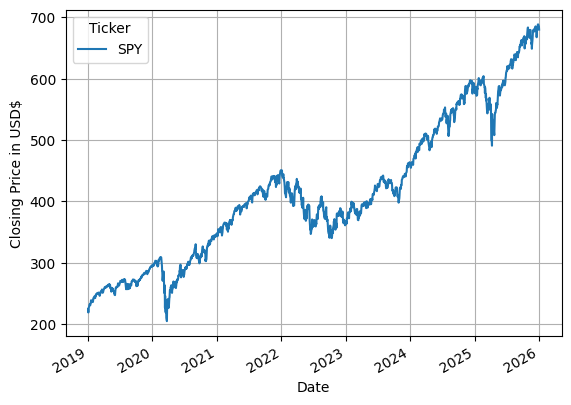

In [155]:
plot_data(df)

In [156]:
#calculate the moving average across a portion of the dataset

In [157]:
def three_day_moving_average_calculation(df):
    try:
        df["3MA"] = df.loc[:, "Close"].rolling(window=3).mean()
        return df
    except Exception as e:
        print(f"an error has occurred: {e}")
    finally:
        print("3 day moving average")

In [158]:
three_day_moving_average_calculation(df)

3 day moving average


Price,Close,High,Low,Open,Volume,3MA
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2019-01-02,224.382523,225.306326,220.588706,220.615611,126925200,NaN
2019-01-03,219.028122,222.938538,218.543797,222.633587,144140700,NaN
2019-01-04,226.364639,227.010397,221.682902,222.059592,142628800,223.258428
2019-01-07,228.149475,229.557577,225.736854,226.633738,103139100,224.514079
2019-01-08,230.292999,230.777325,227.808639,230.337860,102512600,228.269038
...,...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,685.850281
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,687.671956


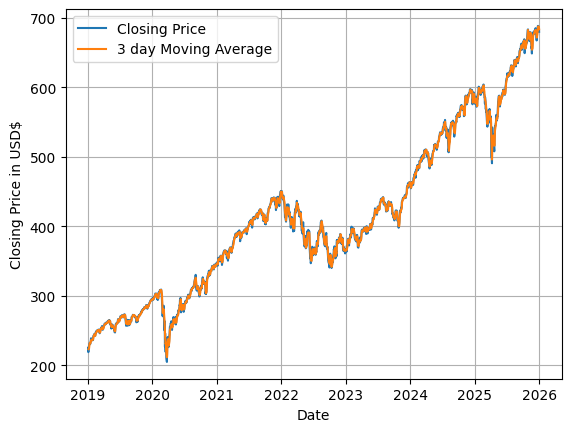

In [159]:
#plot the 3-day moving average
plt.plot(df["Close"], label="Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price in USD$")
plt.plot(df["3MA"], label="3 day Moving Average")
plt.grid(True)
plt.legend(loc=2)
plt.show()

In [160]:
#calculate the 50-day moving average
def fifty_day_moving_average(df):
    try:
        df["50MA"] = df.loc[:, "Close"].rolling(window=50).mean()
        return df
    except Exception as e:
        print(f"an error has occurred:{e}")
    finally:
        print("50 day moving average")

In [161]:
fifty_day_moving_average(df)

50 day moving average


Price,Close,High,Low,Open,Volume,3MA,50MA
Ticker,SPY,SPY,SPY,SPY,SPY,,
Date,,,,,,,
2019-01-02,224.382523,225.306326,220.588706,220.615611,126925200,NaN,NaN
2019-01-03,219.028122,222.938538,218.543797,222.633587,144140700,NaN,NaN
2019-01-04,226.364639,227.010397,221.682902,222.059592,142628800,223.258428,NaN
2019-01-07,228.149475,229.557577,225.736854,226.633738,103139100,224.514079,NaN
2019-01-08,230.292999,230.777325,227.808639,230.337860,102512600,228.269038,NaN
...,...,...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,685.850281,673.116240
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,687.671956,673.656758


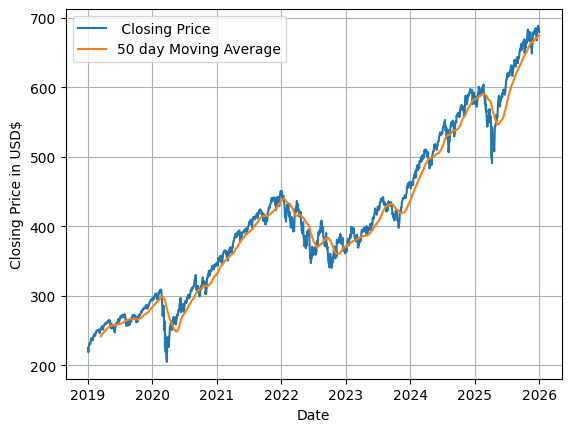

In [162]:
#plot the 50 day moving average
plt.plot(df["Close"], label=" Closing Price")
plt.plot(df["50MA"], label="50 day Moving Average")
plt.xlabel("Date")
plt.ylabel("Closing Price in USD$")
plt.grid(True)
plt.legend(loc=2)
plt.show()

In [163]:
# calculate and plot the 200-day moving average

In [164]:
df["200MA"] = df.loc[:, ["Close"]].rolling(window=200).mean()

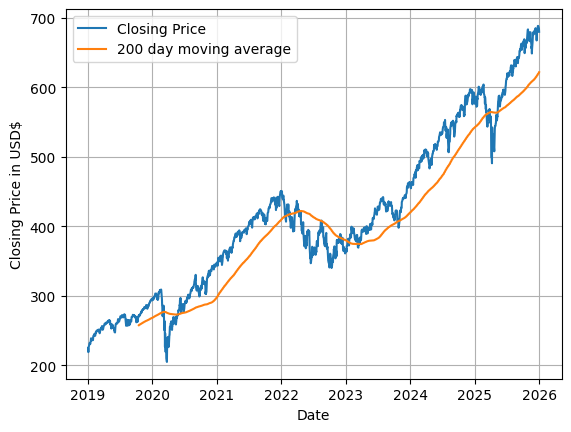

In [165]:
plt.plot(df["Close"], label="Closing Price")
plt.plot(df["200MA"], label="200 day moving average")
plt.xlabel("Date")
plt.ylabel("Closing Price in USD$")
plt.grid(True)
plt.legend(loc=2)
plt.show()

In [166]:
#plot the both the 3, 50 & 200 day moving average for the last 100 days of close price data
def moving_average_plots(df):
    df = df.iloc[-100:, :]
    plt.plot(df['Close'], label="Closing Price")
    plt.plot(df["3MA"],label="3 day moving average")
    plt.plot(df["50MA"], label="50 day moving average")
    plt.plot(df["200MA"], label="200 day moving average")
    plt.xlabel("Date")
    plt.ylabel("Closing Price in USD$")
    plt.grid(True)
    plt.legend(loc=2)
    plt.show()

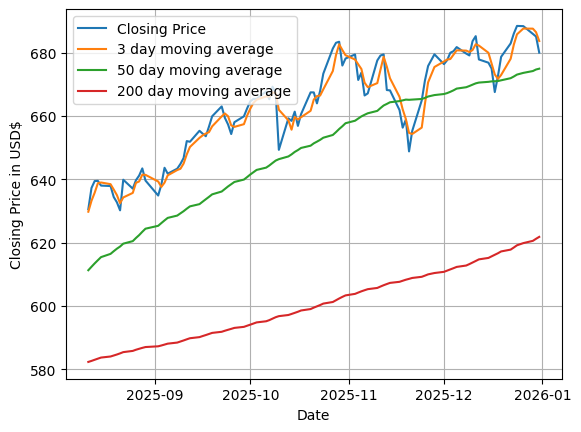

In [167]:
moving_average_plots(df)

In [168]:
# Formulate trading strategy using the moving average

# Take a long position if price > moving average (1)

# Take a short position if price < moving average (-1)

In [169]:
# remove the double header from each column of the data imported from yfinance
df.columns = df.columns.get_level_values(0)

In [170]:
df = df.dropna()

In [171]:
df

Price,Close,High,Low,Open,Volume,3MA,50MA,200MA
Date,,,,,,,,
2019-10-16,271.363892,272.055042,270.927399,271.336611,48928200,270.766754,266.526168,257.775196
2019-10-17,272.164185,273.037197,271.473034,272.527938,45736600,271.776184,266.755948,258.014104
2019-10-18,270.972931,272.273362,270.118096,271.627698,64304000,271.500336,266.859616,258.273828
2019-10-21,272.809875,273.009944,271.855020,272.291541,39048600,271.982330,267.036231,258.506054
2019-10-22,271.918610,273.637354,271.827664,273.346341,48594700,271.900472,267.259290,258.724900
...,...,...,...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,685.850281,673.116240,619.163891
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,687.671956,673.656758,619.851646
2025-12-29,685.976562,687.322922,684.201442,685.667409,62559500,687.635376,674.238296,620.563853


In [172]:
def moving_average_strategy(df):
    df["Strategy"] = np.where(df["Close"] > df["200MA"], -1, 1)
    return df

In [173]:
df = moving_average_strategy(df)

/var/folders/29/cmxsjz7x3p7ct1mhjll72pjh0000gn/T/ipykernel_6158/1313421222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Strategy"] = np.where(df["Close"] > df["200MA"], -1, 1)


In [174]:
df

Price,Close,High,Low,Open,Volume,3MA,50MA,200MA,Strategy
Date,,,,,,,,,
2019-10-16,271.363892,272.055042,270.927399,271.336611,48928200,270.766754,266.526168,257.775196,-1
2019-10-17,272.164185,273.037197,271.473034,272.527938,45736600,271.776184,266.755948,258.014104,-1
2019-10-18,270.972931,272.273362,270.118096,271.627698,64304000,271.500336,266.859616,258.273828,-1
2019-10-21,272.809875,273.009944,271.855020,272.291541,39048600,271.982330,267.036231,258.506054,-1
2019-10-22,271.918610,273.637354,271.827664,273.346341,48594700,271.900472,267.259290,258.724900,-1
...,...,...,...,...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,685.850281,673.116240,619.163891,-1
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,687.671956,673.656758,619.851646,-1
2025-12-29,685.976562,687.322922,684.201442,685.667409,62559500,687.635376,674.238296,620.563853,-1


In [175]:
# calculate the cumulative product of the asset & assess how each strategy compares

In [176]:
df["asset_cumulative_returns"] = np.cumprod(1 + df["Close"].pct_change()) - 1
df["strategy_cumulative_returns"] = np.cumprod(1 + df["Close"].pct_change() * df["Strategy"].shift()) - 1

/var/folders/29/cmxsjz7x3p7ct1mhjll72pjh0000gn/T/ipykernel_6158/1431134252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["asset_cumulative_returns"] = np.cumprod(1 + df["Close"].pct_change()) - 1
/var/folders/29/cmxsjz7x3p7ct1mhjll72pjh0000gn/T/ipykernel_6158/1431134252.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["strategy_cumulative_returns"] = np.cumprod(1 + df["Close"].pct_change() * df["Strategy"].shift()) - 1


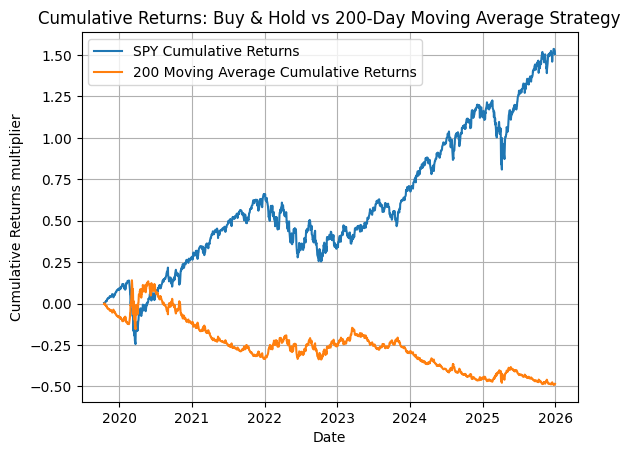

In [177]:
plt.plot(df["asset_cumulative_returns"], label="SPY Cumulative Returns")
plt.plot(df["strategy_cumulative_returns"], label="200 Moving Average Cumulative Returns")
plt.title("Cumulative Returns: Buy & Hold vs 200-Day Moving Average Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns multiplier")
plt.grid(True)
plt.legend(loc=2)
plt.show()